# Cascading task training (multi-label)

Two-stage classifier over the `task_cascading` collection:

1. **Stage 1 — bird detector** (default `sincnet`, fast). Binary:
   bird (target species + `non_target_bird`) vs `no_bird`. Decision is
   `P(bird) >= STAGE1_THRESHOLD`.
2. **Stage 2 — bird classifier** (default `mel_cnn`). Multi-label
   sigmoid over target species + `non_target_bird`; each class fires
   independently when `P >= THRESHOLD`. Trained on bird clips only.

End-to-end probabilities for the 3 target species are composed as
`P(target_c) = P_s1(bird) · P_s2(target_c)`. A clip is reported as
non_target when no target species fires above threshold (after
composition). Metrics mirror `task_train`: per-class precision/recall/
F1/F2 at threshold, macro averages, subset accuracy, one-vs-rest
ROC/AUC, and a true-class × predicted-class fire-rate matrix.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import os

import pyrootutils

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

ROOT = pyrootutils.setup_root(
    search_from=Path.cwd(),
    indicator="pyproject.toml",
    pythonpath=True,
    dotenv=True,
)

## Parameters

In [3]:
from building.geographic_task import base_slug

# COLLECTION here is the cascading on-disk folder (the one ending in
# _cascading). Results are stored under the *base* slug so both standard
# and cascading runs of the same area share one results folder.
COLLECTION = "task_s3_49_2_r50_cascading"
STAGE1_MODEL = "sincnet"   # fast bird/no-bird detector
STAGE2_MODEL = "mel_cnn"   # bird-only species classifier
EPOCHS = 100
PATIENCE = 10
BATCH_SIZE = 16
SEED = 42
THRESHOLD = 0.5          # per-class threshold for stage 2 / cascade
STAGE1_THRESHOLD = 0.5   # P(bird) >= this routes the clip to stage 2

NON_TARGET_BIRD_NAME = "non_target_bird"
NO_BIRD_NAME = "no_bird"
NON_TARGET_NAME = "non_target"

RUN_NAME = f"cascading_{STAGE1_MODEL}__{STAGE2_MODEL}"
RESULTS_FILE = ROOT / "results" / base_slug(COLLECTION) / f"{RUN_NAME}.json"
STAGE1_MODEL_PATH = (
    ROOT / "models" / COLLECTION / f"{STAGE1_MODEL}_stage1.keras"
)
STAGE2_MODEL_PATH = (
    ROOT / "models" / COLLECTION / f"{STAGE2_MODEL}_stage2.keras"
)

## Load dataset catalog

Catalog folders: each target species, `non_target_bird` (other-bird
species, XC/eBird) and `no_bird` (AudioSet + BirdNET no-bird). Stage 1
and stage 2 both source from this single catalog — the cache is shared.

In [4]:
import logging
import warnings

import numpy as np
import tensorflow as tf

tf.get_logger().setLevel("ERROR")
logging.getLogger("absl").setLevel("ERROR")
warnings.filterwarnings("ignore", message=".*AudioResample.*")

from building.scaling import (
    build_grouped_dataset_from_catalog,
    collect_predictions,
    load_dataset_catalog,
    model_factory,
)
from building.models import input_repr_for

catalog = load_dataset_catalog(COLLECTION)

no_bird_idx = catalog.class_names.index(NO_BIRD_NAME)
non_target_bird_idx = catalog.class_names.index(NON_TARGET_BIRD_NAME)
target_idxs = [
    i
    for i, n in enumerate(catalog.class_names)
    if n not in (NO_BIRD_NAME, NON_TARGET_BIRD_NAME)
]
target_names = [catalog.class_names[i] for i in target_idxs]

# Final 4-class label space used for end-to-end metrics: target species first,
# then a pooled non_target that merges both non_target_bird and no_bird.
final_labels = target_names + [NON_TARGET_NAME]
print(f"target_idxs={target_idxs}")
print(f"non_target_bird_idx={non_target_bird_idx}  no_bird_idx={no_bird_idx}")
print(f"final label order: {final_labels}")

target_idxs=[0, 1, 2]
non_target_bird_idx=4  no_bird_idx=3
final label order: ['Emberiza_calandra', 'Hippolais_polyglotta', 'Regulus_ignicapilla', 'non_target']


In [5]:
import pandas as pd

counts = pd.DataFrame(
    [(e.name, e.train.count, e.val.count, e.test.count) for e in catalog.entries],
    columns=["class", "train", "val", "test"],
).set_index("class")
counts["total"] = counts.sum(axis=1)
counts.loc["TOTAL"] = counts.sum(axis=0)

(
    counts.style
    .background_gradient(cmap="Blues", subset=(counts.index[:-1], ["train", "val", "test"]))
    .format("{:,}")
    .set_caption(f"Sample counts per class × split  ({COLLECTION})")
    .set_table_styles([
        {"selector": "caption", "props": [("font-weight", "bold"), ("font-size", "110%"), ("padding", "6px 0")]},
        {"selector": "th", "props": [("text-align", "center")]},
        {"selector": "td", "props": [("text-align", "right"), ("padding", "4px 10px")]},
    ])
)

,train,val,test,total
class,,,,
Emberiza_calandra,"5,727","1,225","1,231","8,183"
Hippolais_polyglotta,"5,430","1,166","1,163","7,759"
Regulus_ignicapilla,"6,926","1,483","1,488","9,897"
no_bird,"9,654","2,069","2,070","13,793"
non_target_bird,"13,762","2,931","2,999","19,692"
TOTAL,"41,499","8,874","8,951","59,324"


## Stage 1 — binary bird detector

Label 0 = `bird` (every target species and `non_target_bird` pooled);
label 1 = `no_bird`. Sigmoid outputs; `P(bird) >= STAGE1_THRESHOLD`
decides routing to stage 2 at inference. Class-balanced sampler reuses
the existing builder.

In [6]:
stage1_groups = [target_idxs + [non_target_bird_idx], [no_bird_idx]]
stage1_label_names = ["bird", NO_BIRD_NAME]
stage1_input_repr = input_repr_for(STAGE1_MODEL)
rng = np.random.default_rng(SEED)

stage1_train, stage1_meta = build_grouped_dataset_from_catalog(
    catalog, stage1_groups, BATCH_SIZE, rng,
    split="train", input_repr=stage1_input_repr, augment=True,
)
stage1_val, _ = build_grouped_dataset_from_catalog(
    catalog, stage1_groups, BATCH_SIZE, rng,
    split="val", input_repr=stage1_input_repr, augment=False,
)
stage1_test, _ = build_grouped_dataset_from_catalog(
    catalog, stage1_groups, BATCH_SIZE, rng,
    split="test", input_repr=stage1_input_repr, augment=False,
)
print(f"stage1: n_classes={stage1_meta.n_classes}  epoch_samples={stage1_meta.epoch_samples}")
for lbl, w in stage1_meta.class_weights.items():
    print(f"  {stage1_label_names[lbl]:<24s} {w:.3f}")

stage1: n_classes=2  epoch_samples=41499
  bird                     0.465
  no_bird                  1.535


In [7]:
tf.keras.backend.clear_session()
stage1_model = model_factory(STAGE1_MODEL)(stage1_meta.n_classes)
stage1_model.summary()

Model: "sincnet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ audio (InputLayer)              │ (None, 48000, 1)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ to_nhwc (Reshape)               │ (None, 48000, 1, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sincnet_convolution             │ (None, 2996, 1, 32)    │            64 │
│ (SincnetConv)                   │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 2996, 1, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ envelope_pool                   │ (None, 749, 1, 32)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ temporal_conv_1 (Conv2D)        │ (None, 375, 1, 16)     │         4,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 375, 1, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ temporal_pool_1                 │ (None, 93, 1, 16)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ temporal_conv_2 (Conv2D)        │ (None, 47, 1, 16)      │         2,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 47, 1, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ final_pool (AveragePooling2D)   │ (None, 1, 1, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,458 (29.13 KB)

 Trainable params: 7,458 (29.13 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
stage1_history = stage1_model.fit(
    stage1_train,
    validation_data=stage1_val,
    epochs=EPOCHS,
    verbose=2,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=PATIENCE,
            restore_best_weights=True,
        ),
    ],
)
print(f"Stopped after {len(stage1_history.history['loss'])} epochs")

Epoch 1/100


I0000 00:00:1779098253.526551 3001381 service.cc:145] XLA service 0x7147b4003710 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779098253.526604 3001381 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
I0000 00:00:1779098255.890379 3001381 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2594/2594 - 79s - 31ms/step - accuracy: 0.8836 - loss: 0.2452 - precision: 0.8839 - recall: 0.8832 - val_accuracy: 0.9053 - val_loss: 0.2384 - val_precision: 0.9052 - val_recall: 0.9056
Epoch 2/100
2594/2594 - 71s - 27ms/step - accuracy: 0.8991 - loss: 0.2235 - precision: 0.8992 - recall: 0.8988 - val_accuracy: 0.9126 - val_loss: 0.2275 - val_precision: 0.9130 - val_recall: 0.9120
Epoch 3/100
2594/2594 - 79s - 31ms/step - accuracy: 0.9091 - loss: 0.2029 - precision: 0.9088 - recall: 0.9091 - val_accuracy: 0.9164 - val_loss: 0.2085 - val_precision: 0.9165 - val_recall: 0.9160
Epoch 4/100
2594/2594 - 73s - 28ms/step - accuracy: 0.9130 - loss: 0.1932 - precision: 0.9128 - recall: 0.9127 - val_accuracy: 0.9203 - val_loss: 0.1984 - val_precision: 0.9208 - val_recall: 0.9198
Epoch 5/100
2594/2594 - 83s - 32ms/step - accuracy: 0.9180 - loss: 0.1857 - precision: 0.9182 - recall: 0.9175 - val_accuracy: 0.9130 - val_loss: 0.2156 - val_precision: 0.9127 - val_recall: 0.9127
Epoch 6/100
2594/2594 

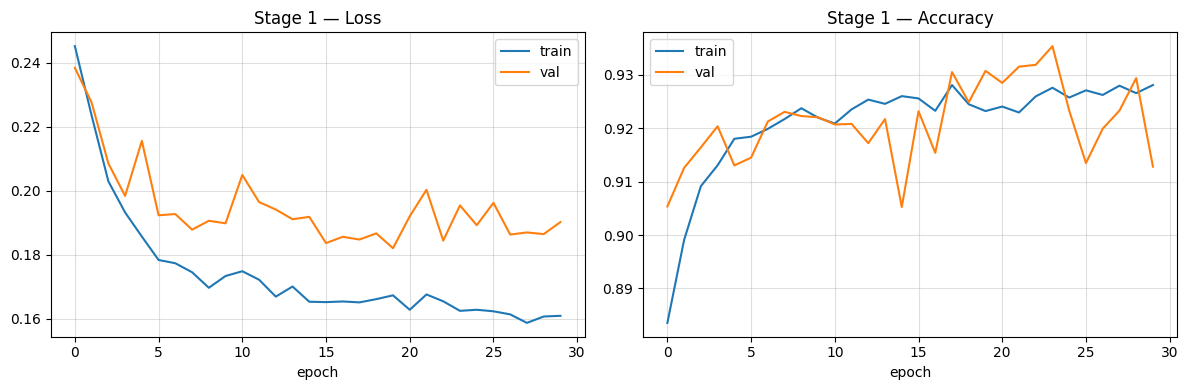

In [9]:
import matplotlib.pyplot as plt

def _plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.history["loss"], label="train")
    axes[0].plot(history.history["val_loss"], label="val")
    axes[0].set_title(f"{title} — Loss")
    axes[0].set_xlabel("epoch")
    axes[0].legend()
    axes[0].grid(alpha=0.4)
    acc_key = next(
        (k for k in ("accuracy", "categorical_accuracy") if k in history.history),
        None,
    )
    if acc_key is not None:
        axes[1].plot(history.history[acc_key], label="train")
        axes[1].plot(history.history[f"val_{acc_key}"], label="val")
        axes[1].set_title(f"{title} — Accuracy")
        axes[1].set_xlabel("epoch")
        axes[1].legend()
        axes[1].grid(alpha=0.4)
    plt.tight_layout()
    plt.show()

_plot_history(stage1_history, "Stage 1")

In [10]:
from sklearn.metrics import roc_auc_score

stage1_test_loss = float(stage1_model.evaluate(stage1_test, verbose=0)[0])
y_true_s1, y_pred_s1 = collect_predictions(stage1_model, stage1_test)
y_true_s1_bin = (y_true_s1 >= 0.5).astype(np.int32)
y_pred_s1_bin = (y_pred_s1 >= STAGE1_THRESHOLD).astype(np.int32)

print(f"Stage 1 test_loss={stage1_test_loss:.4f}  thr={STAGE1_THRESHOLD}")
print(f"{'class':<12s} {'support':>7s} {'prec':>6s} {'rec':>6s} {'f1':>6s}")
print("-" * 44)
stage1_per_class = {}
for c, name in enumerate(stage1_label_names):
    tp = int(((y_true_s1_bin[:, c] == 1) & (y_pred_s1_bin[:, c] == 1)).sum())
    fp = int(((y_true_s1_bin[:, c] == 0) & (y_pred_s1_bin[:, c] == 1)).sum())
    fn = int(((y_true_s1_bin[:, c] == 1) & (y_pred_s1_bin[:, c] == 0)).sum())
    support = int(y_true_s1_bin[:, c].sum())
    prec = tp / max(tp + fp, 1)
    rec = tp / max(tp + fn, 1)
    f1 = (2 * prec * rec / (prec + rec)) if (prec + rec) else 0.0
    stage1_per_class[name] = {
        "support": support, "precision": prec, "recall": rec, "f1": f1,
    }
    print(f"{name:<12s} {support:>7d} {prec:>6.3f} {rec:>6.3f} {f1:>6.3f}")
stage1_auc = float(roc_auc_score(y_true_s1[:, 0], y_pred_s1[:, 0]))
print(f"\nAUC(bird)={stage1_auc:.4f}")

Stage 1 test_loss=0.2246  thr=0.5
class        support   prec    rec     f1
--------------------------------------------
bird            6881  0.946  0.953  0.950
no_bird         2070  0.841  0.819  0.830

AUC(bird)=0.9509


## Stage 2 — bird-only multi-label classifier

Trained only on bird clips: each target species as its own class plus a
pooled `non_target_bird` class. Sigmoid outputs, so multiple species
can fire on the same clip. `no_bird` is skipped entirely — stage 1
filters those out at inference.

In [11]:
stage2_groups = [[i] for i in target_idxs] + [[non_target_bird_idx]]
stage2_label_names = target_names + [NON_TARGET_BIRD_NAME]
stage2_input_repr = input_repr_for(STAGE2_MODEL)

stage2_train, stage2_meta = build_grouped_dataset_from_catalog(
    catalog, stage2_groups, BATCH_SIZE, rng,
    split="train", input_repr=stage2_input_repr, augment=True,
)
stage2_val, _ = build_grouped_dataset_from_catalog(
    catalog, stage2_groups, BATCH_SIZE, rng,
    split="val", input_repr=stage2_input_repr, augment=False,
)
stage2_test, _ = build_grouped_dataset_from_catalog(
    catalog, stage2_groups, BATCH_SIZE, rng,
    split="test", input_repr=stage2_input_repr, augment=False,
)
print(f"stage2: n_classes={stage2_meta.n_classes}  epoch_samples={stage2_meta.epoch_samples}")
for lbl, w in stage2_meta.class_weights.items():
    print(f"  {stage2_label_names[lbl]:<24s} {w:.3f}")

stage2: n_classes=4  epoch_samples=31845
  Emberiza_calandra        1.213
  Hippolais_polyglotta     1.279
  Regulus_ignicapilla      1.003
  non_target_bird          0.505


In [12]:
tf.keras.backend.clear_session()
stage2_model = model_factory(STAGE2_MODEL)(stage2_meta.n_classes)
stage2_model.summary()

Model: "cnn2d_mel"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mel_spectrogram (InputLayer)    │ (None, 184, 80, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 182, 78, 4)     │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 91, 39, 4)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 89, 37, 4)      │           148 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 44, 18, 4)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3168)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 3168)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │        25,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 4)              │            36 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,576 (99.91 KB)

 Trainable params: 25,576 (99.91 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
stage2_history = stage2_model.fit(
    stage2_train,
    validation_data=stage2_val,
    epochs=EPOCHS,
    verbose=2,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=PATIENCE,
            restore_best_weights=True,
        ),
    ],
)
print(f"Stopped after {len(stage2_history.history['loss'])} epochs")

Epoch 1/100
1991/1991 - 68s - 34ms/step - accuracy: 0.6401 - loss: 0.3265 - precision: 0.6697 - recall: 0.5676 - val_accuracy: 0.7289 - val_loss: 0.2482 - val_precision: 0.7059 - val_recall: 0.6240
Epoch 2/100
1991/1991 - 63s - 32ms/step - accuracy: 0.7142 - loss: 0.2436 - precision: 0.7258 - recall: 0.5959 - val_accuracy: 0.7586 - val_loss: 0.2258 - val_precision: 0.7359 - val_recall: 0.6170
Epoch 3/100
1991/1991 - 63s - 32ms/step - accuracy: 0.7435 - loss: 0.2243 - precision: 0.7624 - recall: 0.6377 - val_accuracy: 0.7859 - val_loss: 0.2074 - val_precision: 0.7870 - val_recall: 0.6783
Epoch 4/100
1991/1991 - 64s - 32ms/step - accuracy: 0.7686 - loss: 0.2090 - precision: 0.7923 - recall: 0.6841 - val_accuracy: 0.7962 - val_loss: 0.1961 - val_precision: 0.8114 - val_recall: 0.7124
Epoch 5/100
1991/1991 - 65s - 32ms/step - accuracy: 0.7848 - loss: 0.1959 - precision: 0.8109 - recall: 0.7145 - val_accuracy: 0.8232 - val_loss: 0.1746 - val_precision: 0.8413 - val_recall: 0.7543
Epoch 6/10

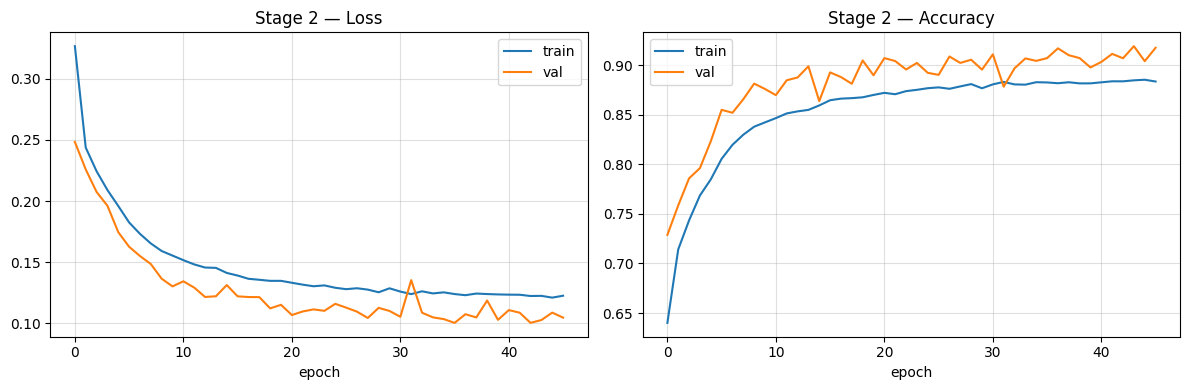

In [14]:
_plot_history(stage2_history, "Stage 2")

In [15]:
stage2_test_loss = float(stage2_model.evaluate(stage2_test, verbose=0)[0])
y_true_s2, y_pred_s2 = collect_predictions(stage2_model, stage2_test)
y_true_s2_bin = (y_true_s2 >= 0.5).astype(np.int32)
y_pred_s2_bin = (y_pred_s2 >= THRESHOLD).astype(np.int32)

print(f"Stage 2 test_loss={stage2_test_loss:.4f}  thr={THRESHOLD}  (bird-only test set)")
print(f"{'class':<28s} {'support':>7s} {'prec':>6s} {'rec':>6s} {'f1':>6s}")
print("-" * 60)
stage2_per_class = {}
for c, name in enumerate(stage2_label_names):
    tp = int(((y_true_s2_bin[:, c] == 1) & (y_pred_s2_bin[:, c] == 1)).sum())
    fp = int(((y_true_s2_bin[:, c] == 0) & (y_pred_s2_bin[:, c] == 1)).sum())
    fn = int(((y_true_s2_bin[:, c] == 1) & (y_pred_s2_bin[:, c] == 0)).sum())
    support = int(y_true_s2_bin[:, c].sum())
    prec = tp / max(tp + fp, 1)
    rec = tp / max(tp + fn, 1)
    f1 = (2 * prec * rec / (prec + rec)) if (prec + rec) else 0.0
    stage2_per_class[name] = {
        "support": support, "precision": prec, "recall": rec, "f1": f1,
    }
    print(f"{name:<28s} {support:>7d} {prec:>6.3f} {rec:>6.3f} {f1:>6.3f}")

Stage 2 test_loss=0.1410  thr=0.5  (bird-only test set)
class                        support   prec    rec     f1
------------------------------------------------------------
Emberiza_calandra               1231  0.854  0.923  0.887
Hippolais_polyglotta            1163  0.863  0.923  0.892
Regulus_ignicapilla             1488  0.924  0.940  0.932
non_target_bird                 2999  0.940  0.852  0.894


## End-to-end cascade evaluation (multi-label)

Run both stages on the same test samples. Cascade probabilities are
composed per target species and `non_target` is implicit:

- `P(target_c) = P_s1(bird) · P_s2(target_c)` for each target species.
- A clip is labelled `non_target` (in the final 4-class label space
  shared with `task_train`) when no target fires at threshold AND
  either stage 1 says no_bird or stage 2's `non_target_bird` fires.

We build two test pipelines from the same catalog — one per stage's
input_repr — with the same group structure that emits 4-class labels
(`non_target_bird` and `no_bird` merged into `non_target`). Test split
has no shuffle and both pipelines use the same `BATCH_SIZE`, so they
iterate the same samples in the same order.

In [16]:
# Final 4-class groups: each target alone, then non_target_bird + no_bird
# pooled as "non_target" — same label space as task_train.
final_groups = [[i] for i in target_idxs] + [[non_target_bird_idx, no_bird_idx]]
n_final = len(final_groups)
non_target_final_idx = n_final - 1
non_target_bird_in_s2 = stage2_label_names.index(NON_TARGET_BIRD_NAME)
bird_in_s1, no_bird_in_s1 = 0, 1

cascade_test_s1, _ = build_grouped_dataset_from_catalog(
    catalog, final_groups, BATCH_SIZE, rng,
    split="test", input_repr=stage1_input_repr, augment=False,
)
cascade_test_s2, _ = build_grouped_dataset_from_catalog(
    catalog, final_groups, BATCH_SIZE, rng,
    split="test", input_repr=stage2_input_repr, augment=False,
)

y_true_chunks = []
s1_chunks, s2_chunks = [], []
for (xb1, yb1), (xb2, yb2) in zip(cascade_test_s1, cascade_test_s2):
    # yb1 and yb2 are identical by construction (same group structure, no
    # shuffle); we keep yb1 as the source of truth.
    y_true_chunks.append(yb1.numpy())
    s1_chunks.append(stage1_model(xb1, training=False).numpy())
    s2_chunks.append(stage2_model(xb2, training=False).numpy())
y_true = np.concatenate(y_true_chunks)
s1_probs = np.concatenate(s1_chunks)
s2_probs = np.concatenate(s2_chunks)
print(f"y_true {y_true.shape}  s1 {s1_probs.shape}  s2 {s2_probs.shape}")

y_true (8951, 4)  s1 (8951, 2)  s2 (8951, 4)


In [17]:
p_bird = s1_probs[:, bird_in_s1]
p_no_bird = s1_probs[:, no_bird_in_s1]

y_pred = np.zeros((y_true.shape[0], n_final), dtype=np.float32)
for c, s2_idx in enumerate(
    [stage2_label_names.index(n) for n in target_names]
):
    y_pred[:, c] = p_bird * s2_probs[:, s2_idx]
# non_target probability: either stage 1 says no_bird, or stage 1 says
# bird and stage 2 fires non_target_bird. Independent-event composition
# (clamped to [0, 1]).
p_non_target = p_no_bird + p_bird * s2_probs[:, non_target_bird_in_s2]
y_pred[:, non_target_final_idx] = np.clip(p_non_target, 0.0, 1.0)

# Hard routing for latency reporting: how many test clips were sent to
# stage 2 by stage 1's threshold?
n_routed_to_s2 = int((p_bird >= STAGE1_THRESHOLD).sum())
print(
    f"Stage 1 routed {n_routed_to_s2}/{len(p_bird)} "
    f"({n_routed_to_s2 / len(p_bird):.1%}) samples to stage 2 "
    f"(thr={STAGE1_THRESHOLD})."
)

Stage 1 routed 6928/8951 (77.4%) samples to stage 2 (thr=0.5).


In [18]:
y_true_bin = (y_true >= 0.5).astype(np.int32)
y_pred_bin = (y_pred >= THRESHOLD).astype(np.int32)

precisions, recalls, f1s, f2s, supports = [], [], [], [], []
print(f"{'class':<28s} {'support':>7s} {'prec':>6s} {'rec':>6s} {'f1':>6s} {'f2':>6s}")
print("-" * 66)
for c, name in enumerate(final_labels):
    tp = int(((y_true_bin[:, c] == 1) & (y_pred_bin[:, c] == 1)).sum())
    fp = int(((y_true_bin[:, c] == 0) & (y_pred_bin[:, c] == 1)).sum())
    fn = int(((y_true_bin[:, c] == 1) & (y_pred_bin[:, c] == 0)).sum())
    support = int(y_true_bin[:, c].sum())
    prec = tp / max(tp + fp, 1)
    rec = tp / max(tp + fn, 1)
    f1 = (2 * prec * rec / (prec + rec)) if (prec + rec) else 0.0
    f2 = (5 * prec * rec / (4 * prec + rec)) if (4 * prec + rec) else 0.0
    precisions.append(prec); recalls.append(rec); f1s.append(f1); f2s.append(f2)
    supports.append(support)
    print(f"{name:<28s} {support:>7d} {prec:>6.3f} {rec:>6.3f} {f1:>6.3f} {f2:>6.3f}")
print("-" * 66)
print(
    f"{'macro':<28s} {sum(supports):>7d} "
    f"{np.mean(precisions):>6.3f} {np.mean(recalls):>6.3f} "
    f"{np.mean(f1s):>6.3f} {np.mean(f2s):>6.3f}"
)
subset_acc = float((y_true_bin == y_pred_bin).all(axis=1).mean())
print(f"\nCascade subset (exact-match) accuracy: {subset_acc:.4f}")

class                        support   prec    rec     f1     f2
------------------------------------------------------------------
Emberiza_calandra               1231  0.848  0.904  0.875  0.892
Hippolais_polyglotta            1163  0.857  0.900  0.878  0.891
Regulus_ignicapilla             1488  0.927  0.821  0.871  0.840
non_target                      5069  0.915  0.916  0.916  0.916
------------------------------------------------------------------
macro                           8951  0.887  0.885  0.885  0.885

Cascade subset (exact-match) accuracy: 0.8753


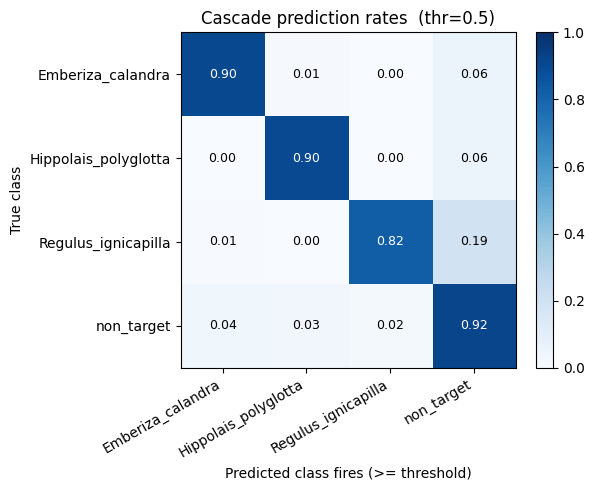

In [19]:
rates = np.zeros((len(final_labels), len(final_labels)), dtype=np.float64)
for i in range(len(final_labels)):
    mask = y_true_bin[:, i] == 1
    if mask.any():
        rates[i] = y_pred_bin[mask].mean(axis=0)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(rates, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(final_labels)))
ax.set_xticklabels(final_labels, rotation=30, ha="right")
ax.set_yticks(range(len(final_labels)))
ax.set_yticklabels(final_labels)
ax.set_xlabel("Predicted class fires (>= threshold)")
ax.set_ylabel("True class")
ax.set_title(f"Cascade prediction rates  (thr={THRESHOLD})")
for i in range(rates.shape[0]):
    for j in range(rates.shape[1]):
        ax.text(
            j, i, f"{rates[i, j]:.2f}",
            ha="center", va="center",
            color="white" if rates[i, j] > 0.5 else "black",
            fontsize=9,
        )
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

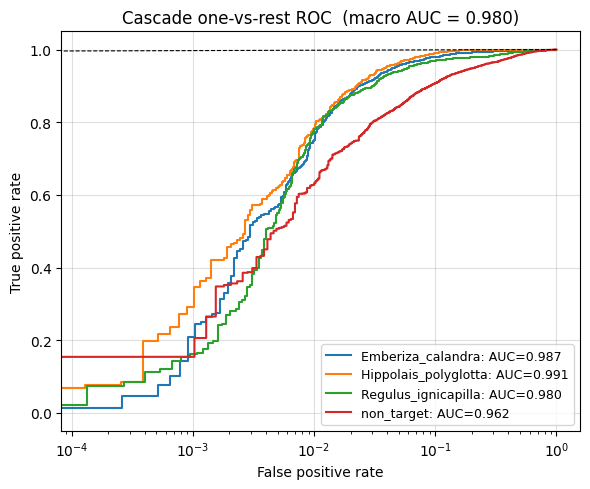

In [20]:
from sklearn.metrics import roc_curve

aucs: list[float] = []
fig, ax = plt.subplots(figsize=(6, 5))
for c, name in enumerate(final_labels):
    try:
        auc = roc_auc_score(y_true[:, c], y_pred[:, c])
        fpr, tpr, _ = roc_curve(y_true[:, c], y_pred[:, c])
    except ValueError as e:
        print(f"skipping {name}: {e}")
        continue
    aucs.append(auc)
    ax.plot(fpr, tpr, label=f"{name}: AUC={auc:.3f}")
ax.plot([0, 1], [0, 1], "k--", lw=0.8)
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_xscale("log")
ax.set_title(f"Cascade one-vs-rest ROC  (macro AUC = {np.mean(aucs):.3f})")
ax.legend(loc="lower right", fontsize=9)
ax.grid(alpha=0.4)
plt.tight_layout()
plt.show()

## Save models and results

In [21]:
import json
from datetime import datetime, timezone

STAGE1_MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
stage1_model.save(STAGE1_MODEL_PATH)
stage2_model.save(STAGE2_MODEL_PATH)
print(f"Saved stage 1: {STAGE1_MODEL_PATH}")
print(f"Saved stage 2: {STAGE2_MODEL_PATH}")

record = {
    "collection": COLLECTION,
    "run_name": RUN_NAME,
    "stage1_model": STAGE1_MODEL,
    "stage2_model": STAGE2_MODEL,
    "timestamp": datetime.now(timezone.utc).isoformat(),
    "epochs_trained": {
        "stage1": len(stage1_history.history["loss"]),
        "stage2": len(stage2_history.history["loss"]),
    },
    "class_names": final_labels,
    "cascade": {
        "subset_accuracy": subset_acc,
        "macro": {
            "precision": float(np.mean(precisions)),
            "recall": float(np.mean(recalls)),
            "f1": float(np.mean(f1s)),
            "f2": float(np.mean(f2s)),
            "auc_ovr": float(np.mean(aucs)) if aucs else None,
        },
        "per_class": {
            name: {
                "support": supports[i],
                "precision": float(precisions[i]),
                "recall": float(recalls[i]),
                "f1": float(f1s[i]),
                "f2": float(f2s[i]),
                "auc_ovr": float(aucs[i]) if i < len(aucs) else None,
            }
            for i, name in enumerate(final_labels)
        },
        "prediction_rates_by_true_class": rates.tolist(),
        "fraction_routed_to_stage2": n_routed_to_s2 / len(p_bird),
    },
    "stage1": {
        "test_loss": stage1_test_loss,
        "auc_bird": stage1_auc,
        "per_class": stage1_per_class,
        "input_repr": stage1_input_repr,
    },
    "stage2": {
        "test_loss": stage2_test_loss,
        "per_class": stage2_per_class,
        "input_repr": stage2_input_repr,
    },
    "hyperparams": {
        "epochs": EPOCHS,
        "patience": PATIENCE,
        "batch_size": BATCH_SIZE,
        "seed": SEED,
        "threshold": THRESHOLD,
        "stage1_threshold": STAGE1_THRESHOLD,
    },
}
RESULTS_FILE.parent.mkdir(parents=True, exist_ok=True)
RESULTS_FILE.write_text(json.dumps(record, indent=2))
print(f"Wrote: {RESULTS_FILE}")

Saved stage 1: /home/nathan/Documents/multi-chirp/models/task_s3_49_2_r50_cascading/sincnet_stage1.keras
Saved stage 2: /home/nathan/Documents/multi-chirp/models/task_s3_49_2_r50_cascading/mel_cnn_stage2.keras
Wrote: /home/nathan/Documents/multi-chirp/results/task_s3_49_2_r50/cascading_sincnet__mel_cnn.json


In [22]:
from building.scaling import cleanup_waveform_cache

cleanup_waveform_cache(COLLECTION)

[cleanup] removed /home/nathan/Documents/multi-chirp/.cache/task_s3_49_2_r50_cascading (11,392.1 MB freed)
